In [1]:
import numpy as np
import math
import mode_analysis_fmm_repo as ma_fmm
import random as rand 
from scipy.stats import maxwell
import matplotlib.pyplot as plt

import sys
# Set this to the path containing the FMM3D Python package on your system.
FMM3D_PYTHON_PATH = "/path/to/FMM3D/python"
sys.path.append(FMM3D_PYTHON_PATH)
import fmm3dpy as fmm

import multiprocessing

Intializing an ion crystal for laser cooling simulations consists of several steps.  First, the ion, trap, and laser beam parameters are set.  Next, the equilibrium configuration of the ion crystal wiht these parameters is computed.  Then the crystal is excited to the speciifed initial temperature.  Finally, the input file, which includes all parameters and ion coordinates is generated.  This file is then used to run the cooling simulation.

In the following cell, we initialize the necessary parameters

In [12]:
#ion parameters
num_ions=100              #number of ions in crystal 
q = 1.602176597458587e-19  #ion charge in C
mass_amu=9.012182          #ion mass in amu

#trap parameters
Bz =4.4588                 #magnetic field in T
wz = 2*np.pi*1.59e6        #axial trapping frequency in rad/sec
wr=220000*2*np.pi          #rotating wall frequency in rad/sec
delta=0.01037493883434892  #relative strength of rotating wall potential

#laser beam parameters
c = 3*10**8                          #speed of light m/s
wavelength_trans = 313*10**-9        #wavelength of laser resonant with cooling transition (meters)
gamma_0_trans = 2.0 * np.pi * 18e6   #transition linewidth, rad/sec

det_pl = -50.*10**6*2*np.pi   #detuning of planar laser beam rad/sec
off_pl = 5.*10**-6             #offset of planar laser beam from trap center (meters)
wst_y_pl = 20*10**-6                                #planar beam waist in y-dir. (meters)
wst_z_pl = 1*10**-4                                #planar beam waist in z-dir. (meters)

det_ax = -5.654867e+07                             #detuning of axial laser beams, here set to -gamma_0_trans/2
                                                   #axial beam is assumed to be centers on origin, ie no offset
wst_x_ax = -1                                      #axial beam waist in y-dir. (-1 signifies an infinite waist)
wst_y_ax = -1                                      #axial beam waist in z-dir. (-1 signifies an infinite waist)

S0_pl = 0.5    #saturation parameter at peak intensity for planar beam 
S0_ax = 0.005  #saturation parameter at peak intensity for axial beams 

#time parameters
dt = 1.0e-9         #timestep in sec
duration = 2.0e-3   #total sim. duration
steps = 2.0e6       #number of steps
write_per = 10000  #write to output file every write_per steps

input_name = 'input/input_100i_091026'  #name of input file to be created

In [6]:
#Additional definitions (do not change these definitions.  Instead, change the parameter values in the cell above)

m = mass_amu*1.66057e-27   #ion mass in kg

wc = q*Bz/m                #cyclotron frequency
frot = wr/(2*np.pi)        #rotating wall freq in Hz
frot_kHz = frot/(1000)     #rotatring wall freq in kHz
v_wall= delta*0.5*m*wz**2 / (1612.*q) #rotating wall strength in code units
kz = m*wz**2 /q            #axial trapping strength
phi0 = np.pi/2             #initial phase of rotaintg wall potential (do not change)

k = 2*np.pi/wavelength_trans                    #wavenumber of resonant laser beam (1/meters)
beam_S0 = [S0_pl,S0_ax,S0_ax]                   #array of saturation parameters
beam_waist = [[0, wst_y_pl, wst_z_pl], [wst_x_ax,wst_y_ax,0], [wst_x_ax,wst_y_ax,0]] #beam waists
beam_disp = [[0,-1*off_pl,0],[0,0,0],[0,0,0]]   #beam displacements from origin
beam_det = [det_pl, det_ax, det_ax]             #beam detunings
beam_k = [[k,0,0],[0,0,k],[0,0,-k]]             #wavevectors of beams
num_beams = len(beam_waist)

Next, we compute the equilibrium configuration of the ion crystal.  This requires the script 'mode_analysis_code_original_fmm'.

In [7]:
method='bfgs' 

#initialize mode analysis
ma_instance=ma_fmm.ModeAnalysis(
                N      = num_ions,
                ionmass= mass_amu,
                B=Bz,
                omega_z = wz,
                Vwall  = v_wall,
                frot   = frot_kHz,
                method = method)

#randomize ion coordinates in a sphere as seed configuration
rad = 2*10**-4 #test
vol = 4/3*np.pi*rad**3
rand_pos_x = np.empty(num_ions)
rand_pos_y = np.empty(num_ions)
rand_pos_z = np.empty(num_ions)
for i in range(num_ions):
    this_vol = rand.random()*vol
    this_rad = (3/(4*np.pi)*this_vol)**(1/3)
    #this_theta = rand.random()*np.pi
    qq = rand.random()
    this_theta = np.arccos(2.*qq-1.)
    this_phi = rand.random()*2*np.pi
    rand_pos_x[i] = this_rad * np.sin(this_theta) * np.cos(this_phi)
    rand_pos_y[i] = this_rad * np.sin(this_theta) * np.sin(this_phi)
    rand_pos_z[i] = this_rad * np.cos(this_theta)

rand_pos = np.concatenate((rand_pos_x,rand_pos_y, rand_pos_z), axis = None)

#find equlibrium
ma_instance.run3D(rand_pos)
print("Cw")
print(ma_instance.Cw)
pos = ma_instance.uE
pos_2D = np.array([pos[:num_ions],pos[num_ions:2*num_ions],pos[2*num_ions:3*num_ions]])
evals = ma_instance.EvalsE3D     #normal mode frequencies
evects = ma_instance.Evects3D    #normal mode vectors
r_vals = ma_instance.r3D         #PE-KE ratio of each mode

False
Desired error not necessarily achieved due to precision loss.
first minimization: 1367.9983044220312
Cw
0.010374938624162444


We can now plot the equilibrium ion configuration.

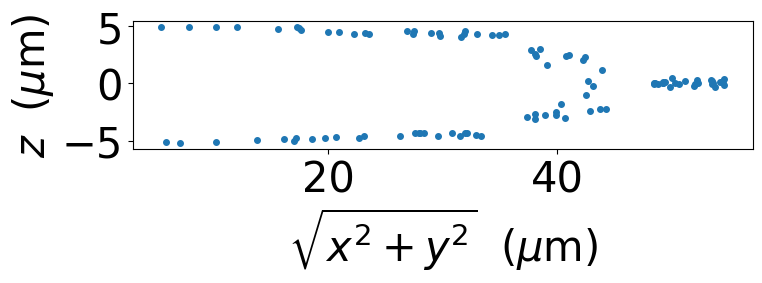

In [8]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot()
ax = fig.axes[0]
ax.plot(np.sqrt(pos_2D[0]**2+pos_2D[1]**2)*10**6, pos_2D[2]*10**6, linestyle = " ", marker = '.', markersize=8)
ax.set_aspect('equal')
ax.set_xlabel(r'$\sqrt{x^2+y^2}\;$ ($\mu$m)', fontsize=30)
ax.set_ylabel(r'$z\;$ ($\mu$m)', fontsize=30)
ax.tick_params(axis='both', labelsize=30)

Next, we excite he crystal's potential energy to a specified initial temperature, here chosen to be 10 mK. Kinetic energy initialization will be described later.

In [9]:
#user-specified params
T=0.01                         #desired crystal temeprature in Kelvin 
step = 5*10**-7                #Metropolis-Hastings step size in meters
MC_iter = 500                  #Number of iterations of Metropolis Hastings algorithm

#constants
Vw = 0.5*(m*wz**2/q)*delta     #rotating wall amplitude
eps0 = 8.85418782*10**-12
kboltz = 1.380649*10**-23

#Metropolis-Hastings algorithm for potential energy initialization at initial temperature 'temp'
rng = np.random.default_rng()
def simulated_annealing_3D(energy, start_pos, n_iterations, step_size, temp,wr):
    best = start_pos.copy()  #lowest energy configuration
    position_list = np.array([[]])
    best_eval = energy(start_pos)  #evaluate the initial point
    energies = np.array([])
    curr = best.copy()
    curr_eval = best_eval
    write_per = 10  #how often to write configuration to position_list
    counter = 0
    #position_list = np.array([start_pos])
    position_list = np.array([start_pos.copy()])
    accept_inc =0
    accept_dec =0
    num_ions = np.size(start_pos[0])
    energies = np.append(energies, energy(curr))
    for i in range(n_iterations):
    # take a step
        print(i)
        for j in range(num_ions):
            add_arr = (rng.random(3)-0.5) * step_size
            curr[:,j] += add_arr
            # evaluate candidate point
            candidate_eval = energy(curr)
            # check for new best solution
            if candidate_eval < best_eval:
                # store new best point
                best = curr.copy()
                best_eval = candidate_eval
                counter+=1
                if counter % write_per == 0:
                    position_list = np.append(position_list, [best.copy()], axis = 0)
            # difference between candidate and current point evaluation
            diff = candidate_eval - curr_eval
            # calculate temperature for current epoch
            t=temp
            # calculate metropolis acceptance criterion
            metropolis = np.exp(-diff / (kboltz*t))
            # check if we should keep the new point
            if diff < 0 or rng.random() < metropolis:
                # store the new current point
                curr_eval = candidate_eval
                energies = np.append(energies, candidate_eval)
                counter+=1
                if diff > 0:
                    #print("energy increase ion " + str(j))
                    accept_inc+=1
                if diff < 0:
                    accept_dec+=1
                    #print("energy decrease ion " + str(j))
            else:
                curr[:,j] -= add_arr
    return [best, best_eval, position_list, curr, accept_dec, accept_inc, energies]



def pot_eng_ax_pl_trap_3D(position):
    shape   = np.shape(position)
    dims,ions=shape
    x = position[0,:]
    y = position[1,:]
    z = position[2,:]
    pot_eng_ion = np.zeros((ions,2))
    #pot_eng_ion = np.zeros((ions,1))
    pot_eng_ion[:,0] = 0.5*m*wz**2*np.square(z)
    pot_eng_ion[:,1] += -0.5*m*(wr**2 - wr*wc + 0.5*wz**2) *(np.square(x)+np.square(y))
    pot_eng_ion[:,1] += q*Vw*(np.square(x)-np.square(y))
    return np.sum(pot_eng_ion)

def pot_eng_coul_3D(position):
    shape   = np.shape(position)
    dims,ions=shape
    x = position[0,:]
    y = position[1,:]
    z = position[2,:]
    pot_eng_ion = np.zeros(ions)
    for ion1 in range(ions):
        for ion2 in range(ions):
            if ion1!=ion2:
                dx = x[ion1] - x[ion2]
                dy = y[ion1] - y[ion2]
                dz = z[ion1] - z[ion2]
                r = np.sqrt(dx**2 + dy**2 + dz**2)
                #r = np.sqrt(dx**2 + dy**2)
                pot_eng_ion[ion1] += q**2/(4*np.pi*eps0*r)
    return np.sum(pot_eng_ion)/2

def pot_eng_coul_3D_fmm(position):
    shape   = np.shape(position)
    dims,ions=shape
    x = position[0,:]
    y = position[1,:]
    z = position[2,:]
    sources = np.array([x,y,z])
    charges = np.full(ions, 1.0)
    fmm_out = fmm.lfmm3d(eps=10**-7, sources=sources,charges=charges,dipvec=None,targets=None,pg=2,pgt=0,nd=1)
    #print(fmm_out.pot)
    Vc_tot = np.sum(fmm_out.pot) * q**2/(4*np.pi*eps0)
    return Vc_tot/2

    
def pot_en_3D(position):
    return pot_eng_ax_pl_trap_3D(position) + pot_eng_coul_3D(position)
#pot_en_3D(start_pos)
#print(pot_en_3D(start_pos))

def pot_en_3D_fmm(position):
    return pot_eng_ax_pl_trap_3D(position) + pot_eng_coul_3D_fmm(position)


pos_MC = simulated_annealing_3D(pot_en_3D_fmm, pos_2D, MC_iter,step,T,wr)

start_pos_x = pos_MC[3][0].copy()
start_pos_y = pos_MC[3][1].copy()
start_pos_z = pos_MC[3][2].copy()

#save ion positions
pos_2D_MC = np.array([start_pos_x,start_pos_y,start_pos_z])
np.savetxt("eq_excited_091026.csv", pos_2D_MC, delimiter = ' ')

#save energies during Metropolis-Hastings initialization
energies_MC = pos_MC[-1]
np.savetxt("energies_091026.csv", energies_MC, delimiter = ' ')


0


We can plot the potential energy during the Metropolis-Hastings initialization to verify that it works successfully.

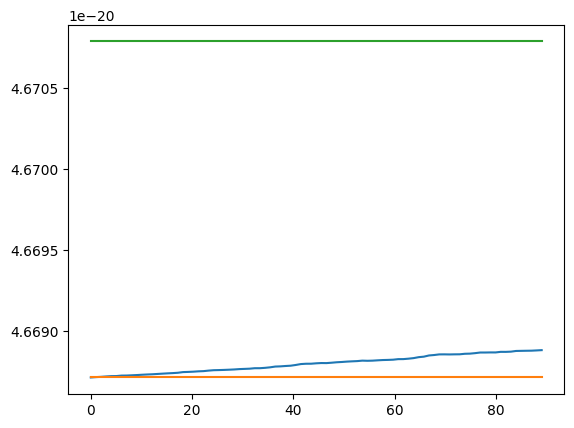

In [10]:
import matplotlib.pyplot as plt


energy_mc = np.loadtxt("energies_091026.csv", delimiter = ' ')
emin = energy_mc[0]
plt.plot(np.linspace(0,energy_mc.size,energy_mc.size), energy_mc)
#initial (equilibrium) energy:
plt.plot(np.linspace(0,energy_mc.size,energy_mc.size), np.full(energy_mc.size,emin)) 
#energy corresponding to 10 mK (three spatial dimensions)
plt.plot(np.linspace(0,energy_mc.size,energy_mc.size), np.full(energy_mc.size,emin+(num_ions*1.5*kboltz*0.01)))  

The following script creates the input file for the simulation.  

In [13]:
start_pos_x = pos_2D_MC[0]
start_pos_y = pos_2D_MC[1]
start_pos_z = pos_2D_MC[2]
vel_x= []
vel_y= []
vel_z = []
m_list = []
q_list=[]
a = np.sqrt(1.381*10**-23*T/(mass_amu*1.66057e-27)) 
#This loop initializes the kinetic energy of the ions at temperature T in the rotating frame of the crystal
for i in range(num_ions):
    total_vel = maxwell.rvs(scale = a)
    qq = rand.random()
    this_theta = np.arccos(2.*qq-1.)
    this_phi = rand.random()*2*np.pi
    vel_x.append(-wr*start_pos_y[i]+total_vel*np.sin(this_theta)*np.cos(this_phi))
    vel_y.append(wr*start_pos_x[i]+total_vel*np.sin(this_theta)*np.sin(this_phi))
    vel_z.append(total_vel*np.cos(this_theta))
    q_list.append(q)
    m_list.append(m)


f = open(str(input_name) + '.txt', 'w')

for i in range(len(start_pos_x)):
    if(i < len(start_pos_x)-1):
        f.write("{:e}".format(start_pos_x[i]) + " ")
    else:
        f.write("{:e}".format(start_pos_x[i]))
f.write("\n")

for i in range(len(start_pos_y)):
    if(i < len(start_pos_y)-1):
        f.write("{:e}".format(start_pos_y[i]) + " ")
    else:
        f.write("{:e}".format(start_pos_y[i]))
f.write("\n")

for i in range(len(start_pos_z)):
    if(i < len(start_pos_z)-1):
        f.write("{:e}".format(start_pos_z[i]) + " ")
    else:
        f.write("{:e}".format(start_pos_z[i]))
f.write("\n")

for i in range(len(vel_x)):
    if(i < len(vel_x)-1):
        f.write("{:e}".format(vel_x[i]) + " ")
    else:
        f.write("{:e}".format(vel_x[i]))
f.write("\n")

for i in range(len(vel_y)):
    if(i < len(vel_y)-1):
        f.write("{:e}".format(vel_y[i]) + " ")
    else:
        f.write("{:e}".format(vel_y[i]))
f.write("\n")

for i in range(len(vel_z)):
    if(i < len(vel_z)-1):
        f.write("{:e}".format(vel_z[i]) + " ")
    else:
        f.write("{:e}".format(vel_z[i]))
f.write("\n")

for i in range(len(q_list)):
    if(i < len(q_list)-1):
        f.write("{:.10e}".format(q_list[i]) + " ")
    else:
        f.write("{:.10e}".format(q_list[i]))
f.write("\n")

for i in range(len(m_list)):
    if(i < len(m_list)-1):
        f.write("{:.10e}".format(m_list[i]) + " ")
    else:
        f.write("{:.10e}".format(m_list[i]))
f.write("\n")

f.write("{:e}".format(dt) + "\n")

f.write("{:e}".format(duration) + "\n")

f.write("{:e}".format(steps) + "\n")

f.write("{:e}".format(write_per) + "\n")

f.write("{:.10e}".format(Bz) + "\n")

f.write("{:.10e}".format(kz) + "\n")

f.write("{:.10e}".format(delta) + "\n")

f.write("{:.10e}".format(wr) + "\n")

f.write("{:.10e}".format(phi0) + "\n")

f.write("{:e}".format(gamma_0_trans))
f.write("\n")

for i in range(num_beams):
    if(i < num_beams-1):
        f.write("{:.10e}".format(beam_S0[i]) + " ")
    else:
        f.write("{:.10e}".format(beam_S0[i]) + " ")
f.write("\n")

for i in range(3):
    for j in range(num_beams):
        if(j < num_beams-1):
            f.write("{:e}".format(beam_k[j][i]) + " ")
        else:
            f.write("{:e}".format(beam_k[j][i]))
    f.write("\n")

for i in range(3):
    for j in range(num_beams):
        if(j < num_beams-1):
            f.write("{:e}".format(beam_waist[j][i]) + " ")
        else:
            f.write("{:e}".format(beam_waist[j][i]))
    f.write("\n")
'''
for i in range(num_beams):
    if(i < num_beams-1):
        f.write("{:e}".format(beam_disp[i]) + " ")
    else:
        f.write("{:e}".format(beam_disp[i]))
f.write("\n")'''

for i in range(3):
    for j in range(num_beams):
        if(j < num_beams-1):
            f.write("{:e}".format(beam_disp[j][i]) + " ")
        else:
            f.write("{:e}".format(beam_disp[j][i]))
    f.write("\n")


for i in range(num_beams):
    if(i < num_beams-1):
        f.write("{:e}".format(beam_det[i]) + " ")
    else:
        f.write("{:e}".format(beam_det[i]))
f.write("\n")


#f.write(str(steps)+ "\n")

f.close()
